In [1]:
from collections import Counter, defaultdict
from dataclasses import dataclass
from typing import Iterable, List, Dict, Tuple, Optional
import math
import time
import urllib.parse
import urllib.request
import json
from pathlib import Path

from tqdm import tqdm
from rdkit import Chem

_fragment_cache = {}

def _load_fragments(fragment_file):
    """
    Load fragments from Heterocyclic_groups.txt file.
    Returns list of (name, SMILES) tuples.
    """
    fragment_path = Path(fragment_file)
    fragments_list = []

    try:
        with open(fragment_path, "r", encoding="utf-8") as f:
            lines = f.readlines()
            for line in lines[1:]:
                line = line.strip()
                if not line:
                    continue

                parts = line.split(",", 1)
                if len(parts) == 2:
                    name = parts[0].strip()
                    smiles = parts[1].strip()
                    if name and smiles:
                        fragments_list.append((name, smiles))
    except Exception as e:
        print(f"Warning: Could not load fragments from {fragment_file}: {e}")
    
    return fragments_list

def _get_fragment_mol(smiles):
    
    if smiles in _fragment_cache:
        return _fragment_cache[smiles]
    
    try:
        mol = Chem.MolFromSmiles(smiles)
        _fragment_cache[smiles] = mol
        return mol
    except Exception:
        _fragment_cache[smiles] = None
        return None

def _count_fragments_in_molecule(smiles, fragment_file):
    
    fragments = _load_fragments(fragment_file)

    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return ""
    except Exception:
        return ""
    
    fragment_counts = []
    
    for name, frag_smiles in fragments:
        frag_mol = _get_fragment_mol(frag_smiles)
        if frag_mol is None:
            fragment_counts.append(0)
            continue
        
        # Count non-overlapping matches
        matches = mol.GetSubstructMatches(frag_mol, uniquify=True)
        fragment_counts.append(len(matches))
    
    # Return as comma-separated string
    return ",".join(str(count) for count in fragment_counts)

@dataclass
class TopNResult:
    target: str
    topn_hit: bool
    best_correct_rank: Optional[int]
    best_correct_count: int
    correct_gens_in_topn: List[str]
    topn_list: List[Tuple[str, int]] 
    total_unique: int
    topn_min_mces: Optional[float]
    topn_max_tanimoto: Optional[float]
    topn_mces_under_thresh_pct: Optional[float]   
    topn_mces_under_thresh_count: int             
    topn_mces_total_count: int                    
    top1_tanimoto_in_pubchem: Optional[bool]  
    top1_tanimoto_smiles: Optional[str]        
    topn_fragment_match: Optional[float]   
    decisiveness: Optional[float]  

_pubchem_cache: Dict[str, bool] = {}
_pubchem_last_request_time: float = 0.0
_PUBCHEM_RATE_LIMIT: float = 0.1  

def _check_smiles_in_pubchem(smiles):
    """
    Check if a SMILES string exists in PubChem using the REST API.
    """

    if smiles in _pubchem_cache:
        return _pubchem_cache[smiles]
    
    # Rate limiting
    global _pubchem_last_request_time
    current_time = time.time()
    time_since_last = current_time - _pubchem_last_request_time
    if time_since_last < _PUBCHEM_RATE_LIMIT:
        time.sleep(_PUBCHEM_RATE_LIMIT - time_since_last)
    _pubchem_last_request_time = time.time()
    
    # Query PubChem API
    try:
        encoded_smiles = urllib.parse.quote(smiles, safe='')
        url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/smiles/{encoded_smiles}/cids/JSON"
        
        with urllib.request.urlopen(url, timeout=10) as response:
            data = json.loads(response.read().decode())
            exists = 'IdentifierList' in data and 'CID' in data['IdentifierList'] and data['IdentifierList']['CID'] != [0]
            _pubchem_cache[smiles] = exists
            return exists

    except Exception:
        # On any error (network, timeout, etc.), assume not in PubChem
        _pubchem_cache[smiles] = False
        return False

def _parse_line(line):

    line = line.strip()
    if not line:
        return None
    parts = line.split()
    if len(parts) < 5:
        return None
    target, generated, identical_s, tanimoto_s, mces_s = parts[:5]
    generated = None if generated == "None" else generated
    try:
        identical = int(float(identical_s))
    except Exception:
        identical = 0
    try:
        tanimoto = float(tanimoto_s)
    except Exception:
        tanimoto = float("nan")
    try:
        mces = float(mces_s)
    except Exception:
        mces = float("nan")
    return (target, generated, identical, tanimoto, mces)

def compute_topn_accuracy(
    file_paths: Iterable[str],
    n: int,
    *,
    ignore_none_generations: bool = True,
    tie_breaker: Optional[str] = None,          
    correctness_rule: str = "any",              
    inclusive_ties: bool = False,               
    mces_threshold: Optional[float] = None,     
    check_pubchem: bool = False,                
    fragment_file: Optional[str] = None,        
):

    counts: Dict[str, Counter] = defaultdict(Counter)      # target -> Counter(gen -> freq)

    # Tie-breaker accumulators (averages)
    tb_sum: Dict[Tuple[str, str], float] = defaultdict(float)
    tb_n: Dict[Tuple[str, str], int] = defaultdict(int)

    # Correctness accumulators
    ident_sum: Dict[Tuple[str, str], int] = defaultdict(int)
    ident_n: Dict[Tuple[str, str], int] = defaultdict(int)

    # Similarity extrema across all rows
    tan_max: Dict[Tuple[str, str], float] = defaultdict(lambda: float("-inf"))  # max observed tanimoto
    mces_min: Dict[Tuple[str, str], float] = defaultdict(lambda: float("inf"))  # min observed mces

    # MCES distribution counts (finite only)
    mces_obs_n: Dict[Tuple[str, str], int] = defaultdict(int)     
    mces_le_n:  Dict[Tuple[str, str], int] = defaultdict(int)     

    all_targets = set()

    for path in file_paths:
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            for line in f:
                parsed = _parse_line(line)
                if not parsed:
                    continue
                target, gen, identical, tanimoto, mces = parsed
                all_targets.add(target)

                if gen is None and ignore_none_generations:
                    continue

                counts[target][gen] += 1

                if gen is not None:
                    # correctness stats
                    ident_sum[(target, gen)] += 1 if identical == 1 else 0
                    ident_n[(target, gen)] += 1

                    # tie-breakers
                    if tie_breaker == "avg_tanimoto" and math.isfinite(tanimoto):
                        tb_sum[(target, gen)] += tanimoto
                        tb_n[(target, gen)] += 1
                    elif tie_breaker == "avg_inv_mces" and math.isfinite(mces):
                        tb_sum[(target, gen)] += 1.0 / (1.0 + mces)
                        tb_n[(target, gen)] += 1

                    # extrema (ignore non-finite)
                    if math.isfinite(tanimoto) and tanimoto > tan_max[(target, gen)]:
                        tan_max[(target, gen)] = tanimoto
                    if math.isfinite(mces) and mces < mces_min[(target, gen)]:
                        mces_min[(target, gen)] = mces

                    if math.isfinite(mces):
                        mces_obs_n[(target, gen)] += 1
                        if (mces_threshold is not None) and (mces <= mces_threshold):
                            mces_le_n[(target, gen)] += 1

    def _avg_tb(target: str, gen: Optional[str]) -> float:
        if gen is None:
            return float("-inf")
        key = (target, gen)
        n_ = tb_n.get(key, 0)
        return (tb_sum[key] / n_) if n_ else float("-inf")

    def _is_correct(target: str, gen: Optional[str]) -> bool:
        if gen is None:
            return False
        key = (target, gen)
        n_ = ident_n.get(key, 0)
        s_ = ident_sum.get(key, 0)
        if n_ == 0:
            return False
        if correctness_rule == "any":
            return s_ > 0
        if correctness_rule == "majority":
            return s_ > (n_ / 2.0)
        if correctness_rule == "all":
            return s_ == n_
        return s_ > 0

    results: List[TopNResult] = []
    denom = 0
    hits = 0

    target_top1_tanimoto: Dict[str, Optional[str]] = {}  # target -> SMILES with highest Tanimoto
    
    for target in sorted(all_targets):

        best_smiles = None
        best_tanimoto = float("-inf")
        
        for gen in counts.get(target, Counter()).keys():
            if gen is None:
                continue
            key = (target, gen)
            tani = tan_max.get(key, float("-inf"))
            if math.isfinite(tani) and tani > best_tanimoto:
                best_tanimoto = tani
                best_smiles = gen
        
        target_top1_tanimoto[target] = best_smiles if best_tanimoto > float("-inf") else None
    

    for target in tqdm(sorted(all_targets)):
        ctr = counts.get(target, Counter())

        items = list(ctr.items())
        if ignore_none_generations:
            items = [(g, c) for g, c in items if g is not None]

        if tie_breaker in ("avg_tanimoto", "avg_inv_mces"):
            items.sort(key=lambda gc: (-gc[1], -_avg_tb(target, gc[0]), gc[0]))
        else:
            items.sort(key=lambda gc: (-gc[1], gc[0]))

        if not inclusive_ties:
            selected = items[:max(0, n)]
        else:
            if len(items) == 0:
                selected = []
            else:
                k = max(1, min(n, len(items)))
                cutoff_freq = items[k-1][1]
                selected = [(g, c) for (g, c) in items if c >= cutoff_freq]
                topn_items = selected
                topn_gens = [g for g, _ in topn_items]

        topn_items = selected
        topn_gens = [g for g, _ in topn_items]

        # correctness within selected set
        correct_in_topn = [g for g in topn_gens if _is_correct(target, g)]

        # extrema across selected gens
        tani_vals = [tan_max.get((target, g), float("-inf")) for g in topn_gens]
        mces_vals = [mces_min.get((target, g), float("inf"))  for g in topn_gens]
        tani_vals = [v for v in tani_vals if math.isfinite(v)]
        mces_vals = [v for v in mces_vals if math.isfinite(v)]
        topn_max_tanimoto = (max(tani_vals) if tani_vals else None)
        topn_min_mces     = (min(mces_vals) if mces_vals else None)

        # percentage under MCES threshold across selected gens (finite only)
        if mces_threshold is not None and topn_gens:
            total_finite = sum(mces_obs_n.get((target, g), 0) for g in topn_gens)
            total_le     = sum(mces_le_n.get((target, g), 0)  for g in topn_gens)
            if total_finite > 0:
                pct = 100.0 * total_le / total_finite
            else:
                pct = None
        else:
            total_finite = 0
            total_le = 0
            pct = None

        top1_smiles = target_top1_tanimoto.get(target, None)
        top1_in_pubchem = None
        if check_pubchem and top1_smiles is not None:
            top1_in_pubchem = _check_smiles_in_pubchem(top1_smiles)

        # Fragment matching: default to None unless we can compute it
        fragment_matches = []
        if fragment_file and topn_gens:
            target_counts = _count_fragments_in_molecule(target, fragment_file)
            if target_counts or any(_count_fragments_in_molecule(g, fragment_file) for g in topn_gens):
                for gen in topn_gens:
                    gen_counts = _count_fragments_in_molecule(gen, fragment_file)
                    fragment_matches.append(1 if gen_counts == target_counts else 0)

        fragment_match = None
        if fragment_matches:
            fragment_match = 1 if 1 in fragment_matches else 0
                    
        best_rank = None
        best_count = 0
        for idx, (g, c) in enumerate(items, start=1):
            if _is_correct(target, g):
                best_rank = idx
                best_count = c
                break

        hit = len(correct_in_topn) > 0
        denom += 1
        hits += int(hit)

        # Calculate decisiveness
        decisiveness = None
        if items:
            top1_count = items[0][1]  # count of top-1 molecule
            total_count = sum(c for _, c in items)  # total count of all generated molecules (excluding None)
            if total_count > 0:
                decisiveness = 100.0 * top1_count / total_count
            else:
                decisiveness = None
        else:
            decisiveness = None

        results.append(TopNResult(
            target=target,
            topn_hit=hit,
            best_correct_rank=best_rank,
            best_correct_count=best_count,
            correct_gens_in_topn=correct_in_topn,
            topn_list=topn_items,
            total_unique=len(items),
            topn_min_mces=topn_min_mces,
            topn_max_tanimoto=topn_max_tanimoto,
            topn_mces_under_thresh_pct=pct,
            topn_mces_under_thresh_count=total_le,
            topn_mces_total_count=total_finite,
            top1_tanimoto_in_pubchem=top1_in_pubchem,
            top1_tanimoto_smiles=top1_smiles,
            topn_fragment_match=fragment_match,
            decisiveness=decisiveness,
        ))

    accuracy = (hits / denom) if denom else 0.0
    return accuracy, results


from dataclasses import dataclass
from typing import Optional, List
import math

@dataclass
class TopNSummary:
    accuracy: float
    avg_topn_min_mces: Optional[float]
    avg_topn_max_tanimoto: Optional[float]
    count_with_mces: int
    count_with_tanimoto: int
    num_targets: int
    pct_targets_min_mces_le_threshold: Optional[float]  
    mces_threshold: Optional[float]
    success_targets_min_mces_le_threshold: int
    denom_for_threshold_pct: int
    pct_top1_tanimoto_in_pubchem: Optional[float]  
    pubchem_checked_count: int                      
    pubchem_found_count: int                      
    avg_topn_fragment_match: Optional[float]   
    fragment_match_count: int                   
    avg_decisiveness: Optional[float]  
    decisiveness_count: int                     

def summarize_topn_results(
    results: List[TopNResult],
    *,
    accuracy: Optional[float] = None,
    mces_threshold: Optional[float] = None,
    threshold_denominator: str = "available",  # "available" (default) or "all"
):

    num_targets = len(results)

    if mces_threshold is None:
        pct = None
        denom = 0
        success = 0
    else:
        has_finite = [(r.topn_min_mces is not None and math.isfinite(r.topn_min_mces)) for r in results]
        success = sum(1 for r in results if (r.topn_min_mces is not None and math.isfinite(r.topn_min_mces) and r.topn_min_mces <= mces_threshold))
        if threshold_denominator == "all":
            denom = num_targets
        else:  # "available"
            denom = sum(1 for v in has_finite if v)

        print (f"denom is {denom}")
        val_gens = sum(1 for v in has_finite if v)
        print (f"num of valid generations {val_gens}")
        print (f"validity: {100*val_gens/denom}%")

        pct = (100.0 * success / denom) if denom > 0 else None

    if accuracy is None:
        hits = sum(1 for r in results if r.topn_hit)
        accuracy = (hits / denom) if denom else 0.0

    mces_vals = [r.topn_min_mces for r in results if (r.topn_min_mces is not None and math.isfinite(r.topn_min_mces))]
    tani_vals = [r.topn_max_tanimoto for r in results if (r.topn_max_tanimoto is not None and math.isfinite(r.topn_max_tanimoto))]

    avg_mces = (sum(mces_vals) / len(mces_vals)) if mces_vals else None
    avg_tani = (sum(tani_vals) / len(tani_vals)) if tani_vals else None


        

    pubchem_results = [r.top1_tanimoto_in_pubchem for r in results if r.top1_tanimoto_in_pubchem is not None]
    total_pubchem_checked = len(pubchem_results)
    total_pubchem_found = sum(1 for r in pubchem_results if r is True)
    if total_pubchem_checked > 0:
        pubchem_pct = 100.0 * total_pubchem_found / total_pubchem_checked
    else:
        pubchem_pct = None

    # Fragment matching statistics
    fragment_vals = [r.topn_fragment_match for r in results if (r.topn_fragment_match is not None and math.isfinite(r.topn_fragment_match))]
    if fragment_vals:
        avg_fragment_match = 100 * sum(fragment_vals) / len(fragment_vals)
        fragment_count = len(fragment_vals)
    else:
        avg_fragment_match = None
        fragment_count = 0

    # Decisiveness statistics
    decisiveness_vals = [r.decisiveness for r in results if (r.decisiveness is not None and math.isfinite(r.decisiveness))]
    if decisiveness_vals:
        avg_decisiveness = sum(decisiveness_vals) / len(decisiveness_vals)
        decisiveness_count = len(decisiveness_vals)
    else:
        avg_decisiveness = None
        decisiveness_count = 0

    return TopNSummary(
        accuracy=accuracy,
        avg_topn_min_mces=avg_mces,
        avg_topn_max_tanimoto=avg_tani,
        count_with_mces=len(mces_vals),
        count_with_tanimoto=len(tani_vals),
        num_targets=num_targets,
        pct_targets_min_mces_le_threshold=pct,
        mces_threshold=mces_threshold,
        success_targets_min_mces_le_threshold=success,
        denom_for_threshold_pct=denom,
        pct_top1_tanimoto_in_pubchem=pubchem_pct,
        pubchem_checked_count=total_pubchem_checked,
        pubchem_found_count=total_pubchem_found,
        avg_topn_fragment_match=avg_fragment_match,
        fragment_match_count=fragment_count,
        avg_decisiveness=avg_decisiveness,
        decisiveness_count=decisiveness_count,
    )

import csv
import math
from typing import List, Optional
import pandas as pd
import numpy as np

def export_topn_csv(
    results: List[TopNResult],
    csv_path: str,
    *,
    n: Optional[int] = None,
    mces_threshold: Optional[float] = None,
    include_lists: bool = False,
):
    fields = [
        "target",
        "n",
        "mces_threshold",
        "topn_hit",
        "topn_hit_int",
        "best_correct_rank",
        "best_correct_count",
        "total_unique",
        "topn_min_mces",
        "topn_max_tanimoto",
        "topn_min_mces_le_threshold",
        "top1_tanimoto_in_pubchem",
        "top1_tanimoto_in_pubchem_int",
        "top1_tanimoto_smiles",
        "topn_fragment_match",
        "decisiveness",
    ]
    if include_lists:
        fields += ["correct_gens_in_topn", "topn_list"]

    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fields)
        writer.writeheader()
        for r in results:
            meets = (
                mces_threshold is not None
                and r.topn_min_mces is not None
                and math.isfinite(r.topn_min_mces)
                and r.topn_min_mces <= mces_threshold
            )
            row = {
                "target": r.target,
                "n": n,
                "mces_threshold": mces_threshold,
                "topn_hit": bool(r.topn_hit),
                "topn_hit_int": int(bool(r.topn_hit)),
                "best_correct_rank": r.best_correct_rank,
                "best_correct_count": r.best_correct_count,
                "total_unique": r.total_unique,
                "topn_min_mces": None if r.topn_min_mces is None else float(r.topn_min_mces),
                "topn_max_tanimoto": None if r.topn_max_tanimoto is None else float(r.topn_max_tanimoto),
                "topn_min_mces_le_threshold": int(bool(meets)),
                "top1_tanimoto_in_pubchem": bool(r.top1_tanimoto_in_pubchem) if r.top1_tanimoto_in_pubchem is not None else None,
                "top1_tanimoto_in_pubchem_int": int(bool(r.top1_tanimoto_in_pubchem)) if r.top1_tanimoto_in_pubchem is not None else None,
                "top1_tanimoto_smiles": r.top1_tanimoto_smiles,
                "topn_fragment_match": None if r.topn_fragment_match is None else float(r.topn_fragment_match),
                "decisiveness": None if r.decisiveness is None else float(r.decisiveness),
            }
            if include_lists:
                row["correct_gens_in_topn"] = ";".join(r.correct_gens_in_topn)
                row["topn_list"] = ";".join(f"{g}|{c}" for g, c in r.topn_list)
            writer.writerow(row)


def export_top5_smiles_csv(
    results: List[TopNResult],
    csv_path: str,
    *,
    top_n: int = 5,
):
    """
    Export a CSV file with target SMILES and top-N generated SMILES with their occurrence counts.
    """
    rows = []
    for r in results:
        row = {"target": r.target}
        
        # Get top-N generated SMILES with counts
        topn_items = r.topn_list[:top_n] if r.topn_list else []
        
        # Fill in SMILES and counts, pad with NaN if fewer than top_n
        for i in range(1, top_n + 1):
            if i <= len(topn_items):
                smiles, count = topn_items[i - 1]
                row[f"gen_smiles_{i}"] = smiles if smiles is not None else np.nan
                row[f"gen_count_{i}"] = count if count is not None else np.nan
            else:
                row[f"gen_smiles_{i}"] = np.nan
                row[f"gen_count_{i}"] = np.nan
        
        rows.append(row)
    
    # Create DataFrame and write to CSV
    df = pd.DataFrame(rows)
    df.to_csv(csv_path, index=False, na_rep="")


def compute_topn_accuracy_with_summary(
    *args,
    write_csv: bool = False,
    csv_path: str = None,
    csv_include_lists: bool = False,
    write_top5_smiles_csv: bool = False,
    top5_smiles_csv_path: str = None,
    threshold_denominator = "available",
    **kwargs
):
    """
    Convenience wrapper. All other args/kwargs go to compute_topn_accuracy (incl. mces_threshold, check_pubchem, fragment_file).
    """
    acc, results = compute_topn_accuracy(*args, **kwargs)
    mces_threshold = kwargs.get("mces_threshold", None)

    summary = summarize_topn_results(
        results, accuracy=acc, mces_threshold=mces_threshold,
        threshold_denominator=threshold_denominator
    )

    if write_csv:
        if not csv_path:
            raise ValueError("write_csv=True but no csv_path was provided.")
        # get n for CSV from kwargs or positional args
        n_val = kwargs.get("n", None)
        if n_val is None and len(args) >= 2:
            n_val = args[1]
        export_topn_csv(
            results, csv_path,
            n=n_val,
            mces_threshold=mces_threshold,
            include_lists=csv_include_lists
        )

    if write_top5_smiles_csv:
        if not top5_smiles_csv_path:
            raise ValueError("write_top5_smiles_csv=True but no top5_smiles_csv_path was provided.")
        export_top5_smiles_csv(
            results, top5_smiles_csv_path,
            top_n=5
        )

    return summary, results


In [2]:
import math
import re
from pathlib import Path
from typing import Optional, Literal

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rdkit import Chem  # type: ignore


def count_atoms_smiles(smiles: str) -> Optional[int]:
    """
    Returns number of explicit atoms in SMILES
    """
    if not isinstance(smiles, str) or not smiles.strip():
        return None

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return int(mol.GetNumAtoms())



def atom_bin_label(atom_count: int, bin_size: int = 5, upper_limit: Optional[int] = None, overflow: str = "unbounded") -> str:
    """Return a label like "0-5", "6-10", ... using the provided bin_size.
    
    If upper_limit is provided, values above it are handled according to overflow mode:
    - "unbounded": creates a label like "30+" for values above upper_limit
    - "bin": creates a label like ">29" for values above upper_limit
    - "drop": returns None for values above upper_limit
    - "clip": treats values above upper_limit as equal to upper_limit
    
    When upper_limit is set and atom_count is within the last bin that would exceed it,
    the bin is capped at upper_limit (e.g., with bin_size=5 and upper_limit=29, 
    atom_count 26-29 creates bin "26-29" instead of "26-30").

    The lower bin is always ``0–bin_size`` and all subsequent bins have width
    ``bin_size`` as well, e.g. ``bin_size=10`` → ``0-10, 11-20, 21-30, ...``.
    """
    # Handle overflow cases first
    if upper_limit is not None and atom_count > upper_limit:
        if overflow == "bin":
            return f">{upper_limit}"
        elif overflow == "drop":
            return None
        elif overflow == "clip":
            atom_count = upper_limit  # fall through to numeric binning
        elif overflow == "unbounded":
            if upper_limit <= bin_size:
                unbounded_start = bin_size + 1
            else:
                last_bin_lo = ((upper_limit - 1) // bin_size) * bin_size + 1
                last_bin_hi = last_bin_lo + (bin_size - 1)
                unbounded_start = last_bin_hi + 1
            return f"{unbounded_start}+"
    
    # Calculate bin bounds
    if atom_count <= bin_size:
        lo, hi = 0, bin_size
    else:
        lo = ((atom_count - 1) // bin_size) * bin_size + 1
        hi = lo + (bin_size - 1)
    
    # Cap the last bin at upper_limit if it would exceed it
    if upper_limit is not None:
        # Calculate what the last bin should be
        last_bin_lo = ((upper_limit - 1) // bin_size) * bin_size + 1
        # If this atom_count falls in the last bin (lo >= last_bin_lo), cap hi at upper_limit
        if lo >= last_bin_lo:
            hi = upper_limit
    
    return f"{lo}-{hi}"

def atom_bin_bounds(label: str) -> tuple[int, int]:
    """Parse bin label and return (lo, hi) bounds.
    
    Supports "lo-hi", overflow labels like ">29", and unbounded labels like "30+".
    """
    if label.startswith(">"):
        k = int(label[1:])
        return (k + 1, k + 1)  # ensures it sorts after numeric bins
    elif label.endswith("+"):
        k = int(label[:-1])
        return (k, float('inf'))  # unbounded on the upper side, sorts last
    lo, hi = label.split("-")
    return int(lo), int(hi)


MetricName = Literal["accuracy", "topn_min_mces", "topn_max_tanimoto", "pct_targets_min_mces", "decisiveness", "fragment_match"]

def plot_metric_by_atom_bins(
    csv_path,
    metric: MetricName,
    n,
    *,
    yticks = None,
    bin_size: int = 5,
    save_path = None,
    show_values_on_bars: bool = True,
):
    """
    Aggregates the chosen metric per atom-count bin and draws a bar chart.
    """
    csv_path = Path(csv_path)
    df = pd.read_csv(csv_path)

    for col in ["topn_hit_int", "topn_min_mces", "topn_max_tanimoto", "topn_min_mces_le_threshold", "topn_fragment_match", "decisiveness"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Count atoms per target (drop rows we can't parse)
    df["atom_count"] = df["target"].apply(count_atoms_smiles)
    df = df.dropna(subset=["atom_count"]).copy()
    df["atom_count"] = df["atom_count"].astype(int)

    # Make bin labels
    df["atom_bin"] = df["atom_count"].apply(lambda x: atom_bin_label(x, bin_size=bin_size))

    # Choose metric column + aggregation
    if metric == "accuracy":
        col = "topn_hit_int"
        agg = lambda s: float(s.dropna().mean()) * 100.0  # percentage
        ylabel = f"Accuracy (%)"
    elif metric == "topn_min_mces":
        col = "topn_min_mces"
        agg = lambda s: float(s.dropna().mean())  # mean MCES
        ylabel = f"Mean MCES"
    elif metric == "topn_max_tanimoto":
        col = "topn_max_tanimoto"
        agg = lambda s: float(s.dropna().mean())  # mean Tanimoto
        ylabel = f"Mean Tanimoto"
    elif metric == "pct_targets_min_mces":
        col = "topn_min_mces_le_threshold"  # 0/1 flag per target
        agg = lambda s: float(s.dropna().mean()) * 100.0  # percentage
        ylabel = f"% Targets with MCES ≤ 6"
    elif metric == "decisiveness":
        col = "decisiveness"
        agg = lambda s: float(s.dropna().mean())  # mean decisiveness (already in percentage)
        ylabel = f"Mean Decisiveness (%)"
    elif metric == "fragment_match":
        col = "topn_fragment_match"
        agg = lambda s: float(s.dropna().mean()) * 100.0  # percentage
        ylabel = f"Fragment Match (%)"
    else:
        raise ValueError(f"Unknown metric: {metric}")

    # Aggregate per bin
    grouped = df.groupby("atom_bin")[col].apply(agg).reset_index(name="value")
    counts = df.groupby("atom_bin")["target"].count().reset_index(name="count")
    out = pd.merge(grouped, counts, on="atom_bin", how="outer").fillna(0)

    # Expand bin bounds for sorting and downstream use
    out["bin_lo"], out["bin_hi"] = zip(*out["atom_bin"].map(atom_bin_bounds))
    out = out.rename(columns={"atom_bin": "bin"}).sort_values(["bin_lo", "bin_hi"]).reset_index(drop=True)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    x = np.arange(len(out))
    
    # Use ambient color (soft teal/blue)
    bar_color = '#6B9BD1'  # Soft blue
    bars = ax.bar(x, out["value"], color=bar_color, edgecolor='#4A7BA7', linewidth=0.5)
    
    ax.set_xticks(x)
    ax.set_xticklabels(out["bin"], rotation=0, fontsize=15)

    if yticks != None:
        ax.set_yticks(np.arange(yticks[0], yticks[1]+yticks[2], yticks[2]))
        ax.set_ylim(yticks[0], yticks[1]) 

    ax.set_xlabel("Number of atoms", fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.tick_params(axis='y', labelsize=15)
    # ax.set_title(f"{ylabel} by Atom Count (bin={bin_size})")
    
    # Remove top and right borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Optionally annotate bars
    if show_values_on_bars:
        for xi, val in zip(x, out["value"].values):
            if isinstance(val, (float, int)) and not (isinstance(val, float) and math.isnan(val)):
                ax.text(xi, val, f"{val:.3g}", ha="center", va="bottom", fontsize=12)

    plt.tight_layout()
    if save_path:
        # Default to SVG if no extension provided
        if not any(save_path.endswith(ext) for ext in ['.svg', '.png', '.pdf', '.jpg', '.jpeg', '.eps']):
            save_path = str(save_path) + '.png'
        plt.savefig(save_path, bbox_inches="tight", format='svg' if save_path.endswith('.svg') else None, dpi=150)
    plt.show()

    return out[["bin", "bin_lo", "bin_hi", "count", "value"]]


In [3]:
import math
from pathlib import Path
from typing import Dict, Any, Optional, Literal, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MetricName = Literal["accuracy", "topn_min_mces", "topn_max_tanimoto", "pct_targets_min_mces", "decisiveness"]
OverflowMode = Literal["bin", "drop", "clip", "unbounded"]

def _first_size(x) -> Optional[int]:
    if not isinstance(x, (list, tuple)) or len(x) == 0:
        return None
    first = x[0]
    try:
        return int(len(first))
    except Exception:
        if hasattr(first, "shape") and getattr(first, "shape") is not None and len(first.shape) > 0:
            try:
                return int(first.shape[0])
            except Exception:
                return None
    return None

def _size_bin_label(
    sz: int,
    *,
    bin_size: int = 5,
    upper_limit: Optional[int] = None,
    overflow: OverflowMode = "bin"
):

    if upper_limit is not None and sz > upper_limit:
        if overflow == "bin":
            return f">{upper_limit}"
        elif overflow == "drop":
            return None
        elif overflow == "clip":
            sz = upper_limit  # fall through to numeric binning
        elif overflow == "unbounded":
            if upper_limit <= bin_size:
                unbounded_start = bin_size + 1
            else:
                last_bin_lo = ((upper_limit - 1) // bin_size) * bin_size + 1
                last_bin_hi = last_bin_lo + (bin_size - 1)
                unbounded_start = last_bin_hi + 1
            return f"{unbounded_start}+"

    if sz <= bin_size:
        lo, hi = 0, bin_size
    else:
        lo = ((sz - 1) // bin_size) * bin_size + 1
        hi = lo + (bin_size - 1)
    return f"{lo}-{hi}"

def _bin_bounds(label: str) -> tuple[int, int]:
    # Supports "lo-hi", overflow labels like ">30", and unbounded labels like "31+"
    if label.startswith(">"):
        k = int(label[1:])
        return (k + 1, k + 1)  # ensures it sorts after numeric bins
    elif label.endswith("+"):
        k = int(label[:-1])
        return (k, float('inf'))  # unbounded on the upper side, sorts last
    lo, hi = label.split("-")
    return int(lo), int(hi)

def plot_metric_by_(
    smiles_dict: Dict[str, Any],
    metrics: Union[str, Path, pd.DataFrame],
    metric: MetricName,
    n,
    *,
    yticks = None,
    bin_size: int = 5,
    upper_limit: Optional[int] = None,
    overflow: OverflowMode = "bin",
    save_path: Optional[Union[str, Path]] = None,
    show_values_on_bars: bool = True,
) -> pd.DataFrame:
    """
    Bar-chart histogram of a metric vs. data depth.
    """
    # 1) sizes from dict
    size_rows = []
    for tgt, lst in smiles_dict.items():
        sz = _first_size(lst)
        if sz is not None:
            size_rows.append((tgt, sz))
    sizes_df = pd.DataFrame(size_rows, columns=["target", "first_size"])

    # 2) load metrics
    if isinstance(metrics, (str, Path)):
        met_df = pd.read_csv(metrics)
    elif isinstance(metrics, pd.DataFrame):
        met_df = metrics.copy()
    else:
        raise TypeError("`metrics` must be a CSV path or a pandas DataFrame")

    for col in ["topn_hit_int", "topn_min_mces", "topn_max_tanimoto", "topn_min_mces_le_threshold", "decisiveness"]:
        if col in met_df.columns:
            met_df[col] = pd.to_numeric(met_df[col], errors="coerce")

    # 3) merge
    df = sizes_df.merge(met_df, on="target", how="inner")

    # 4) choose metric + aggregator
    if metric == "accuracy":
        col = "topn_hit_int"
        ylabel = f"Accuracy (%)"
        agg_fn = lambda s: float(s.dropna().mean() * 100.0) if len(s.dropna()) else float("nan")
    elif metric == "topn_min_mces":
        col = "topn_min_mces"
        ylabel = f"Mean MCES"
        agg_fn = lambda s: float(s.dropna().mean()) if len(s.dropna()) else float("nan")
    elif metric == "topn_max_tanimoto":
        col = "topn_max_tanimoto"
        ylabel = f"Mean Tanimoto"
        agg_fn = lambda s: float(s.dropna().mean()) if len(s.dropna()) else float("nan")
    elif metric == "pct_targets_min_mces":
        col = "topn_min_mces_le_threshold"
        ylabel = "% Targets with min(MCES) ≤ 6"
        agg_fn = lambda s: float(s.dropna().mean() * 100.0) if len(s.dropna()) else float("nan")
    elif metric == "decisiveness":
        col = "decisiveness"
        ylabel = "Mean Decisiveness (%)"
        agg_fn = lambda s: float(s.dropna().mean()) if len(s.dropna()) else float("nan")
    else:
        raise ValueError(f"Unknown metric: {metric}")

    # 5) bin by first_size with upper-limit control
    df["size_bin"] = df["first_size"].apply(
        lambda x: _size_bin_label(int(x), bin_size=bin_size, upper_limit=upper_limit, overflow=overflow)
    )
    # drop rows that were intentionally dropped by overflow="drop"
    df = df.dropna(subset=["size_bin"]).copy()

    # 6) aggregate
    grouped = df.groupby("size_bin")[col].apply(agg_fn).reset_index(name="value")
    counts = df.groupby("size_bin")["target"].count().reset_index(name="count")
    out = pd.merge(grouped, counts, on="size_bin", how="outer").fillna(0)

    # 7) sort by numeric bounds (overflow bin ends up last)
    out["bin_lo"], out["bin_hi"] = zip(*out["size_bin"].map(_bin_bounds))
    out = out.rename(columns={"size_bin": "bin"}).sort_values(["bin_lo", "bin_hi"]).reset_index(drop=True)

    # 8) plot
    fig, ax = plt.subplots(figsize=(8, 6))
    x = np.arange(len(out))
    
    # Use ambient color (soft teal/blue)
    bar_color = '#6B9BD1'  # Soft blue
    bars = ax.bar(x, out["value"], color=bar_color, edgecolor='#4A7BA7', linewidth=0.5)
    
    ax.set_xticks(x)
    ax.set_xticklabels(out["bin"], fontsize=12)
    
    if yticks is not None:
        ax.set_yticks(np.arange(yticks[0], yticks[1] + yticks[2], yticks[2]))
        ax.set_ylim(yticks[0], yticks[1])
        
    ax.set_xlabel("data depth", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.tick_params(axis='y', labelsize=12)

    title_suffix = f", cap={upper_limit}" if upper_limit is not None else ""
    # ax.set_title(f"{ylabel} by data-depth (bin={bin_size}{title_suffix})")
    
    # Remove top and right borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if show_values_on_bars:
        for xi, val in zip(x, out["value"].values):
            if isinstance(val, (int, float)) and not (isinstance(val, float) and math.isnan(val)):
                ax.text(xi, val, f"{val:.3g}", ha="center", va="bottom", fontsize=12)

    plt.tight_layout()
    if save_path:
        # Default to SVG if no extension provided
        if not any(save_path.endswith(ext) for ext in ['.svg', '.png', '.pdf', '.jpg', '.jpeg', '.eps']):
            save_path = str(save_path) + '.png'
        plt.savefig(save_path, bbox_inches="tight", format='svg' if save_path.endswith('.svg') else None, dpi=150)
    plt.show()

    return out[["bin", "bin_lo", "bin_hi", "count", "value"]]


## Post-Analysis Workflow

This notebook is organized into three main sections:

### 1. Simple Analysis
Computes overall metrics and summary statistics for the MS2Mol model performance:
- **Validity**: Percentage of generated SMILES strings that are chemically valid (typically >99%)
- **Top-N Accuracy**: Percentage of test targets where the correct molecule appears in the top-N generated candidates
- **Average Top-N Minimum MCES**: Mean of the minimum Maximum Common Edge Subgraph distance (lower is better)
- **Average Top-N Maximum Tanimoto**: Mean of the maximum Tanimoto similarity coefficient (higher is better, range 0-1)
- **MCES Threshold Success Rate**: Percentage of targets where at least one generated molecule has MCES ≤ threshold
- **Decisiveness**: A metric measuring model confidence in top predictions
- **Fragment Match Score**: Average fragment matching score between generated and target molecules

All metrics are exported to CSV files in `analysis_outputs/` for further analysis.

### 2. Plotting by Atom Count
Analyzes performance metrics stratified by molecule size (number of atoms):
- Top-N accuracy by atom count
- Decisiveness by atom count
- Mean Top-N min MCES by atom count
- Mean Top-N max Tanimoto by atom count

Plots are saved to `analysis_outputs/plots/` directory.

### 3. Plotting by Data Depth
Analyzes performance metrics stratified by MS spectrum complexity (number of peaks/spectra):
- Top-N min MCES by data depth
- Decisiveness by data depth
- Top-N accuracy by data depth

This analysis helps understand how model performance varies with the complexity of the input MS spectrum.

### 1. Simple Analysis

In [ ]:
# Compute overall metrics and summary statistics

import os

n = 5
mces_threshold = 6.0
pubchem_check = False

# analysis_folder_path_1 = "/gpfs0/bgu-anatm/users/harniky/ms2mol/MS_diffusion/outputs/2026-03-02/16-14-54-test_NIST_ms2fp_random"
# analysis_folder_path_2 = "/gpfs0/bgu-anatm/users/harniky/ms2mol/MS_diffusion/outputs/2026-03-02/16-03-16-test_NIST_ms2emb_random"

analysis_folder_path = "/gpfs0/bgu-anatm/users/harniky/ms2mol/MS_diffusion/outputs/Inference/NIST_random_tempvar_25"
name = os.path.split(analysis_folder_path)[1]

# Automatically find all final_smiles*.txt files in the analysis folder
import glob
files = sorted(glob.glob(os.path.join(analysis_folder_path, "final_smiles*.txt")))
print(f"Found {len(files)} final_smiles files to process")

# Create CSV output directory
csv_dir = "analysis_outputs/csv"
os.makedirs(csv_dir, exist_ok=True)

csv_filename = f"{name}_top{n}_PUBCHEM.csv" if pubchem_check else f"{name}_top{n}.csv"
csv_path = os.path.join(csv_dir, csv_filename)

summary, results = compute_topn_accuracy_with_summary(
    files, n=n,
    fragment_file="/gpfs0/gaus/users/harniky/ms2mol/MS_diffusion/src/metrics/Fragment_groups.txt",
    ignore_none_generations=True,
    tie_breaker="avg_tanimoto",
    correctness_rule="any",
    inclusive_ties=False,
    mces_threshold=mces_threshold,
    threshold_denominator='all',
    check_pubchem=pubchem_check,
    write_csv=True,
    csv_path=csv_path
)

print(f"Top-{n} accuracy: {summary.accuracy:.2%}")
print(f"Avg top-{n} min MCES: {summary.avg_topn_min_mces:.2f}")
print(f"Avg top-{n} max Tanimoto: {summary.avg_topn_max_tanimoto:.3f}")
print(f"% targets with min(MCES) ≤ {mces_threshold}: {summary.pct_targets_min_mces_le_threshold:.2f}% "
      f"({summary.success_targets_min_mces_le_threshold}/{summary.denom_for_threshold_pct})")
print(f"Avg fragment match: {summary.avg_topn_fragment_match:.2f}%")

if summary.avg_decisiveness is not None:
    print(f"Avg decisiveness: {summary.avg_decisiveness:.2f}%")

if pubchem_check:
    print(f"% of generated SMILES in PubChem: {summary.pct_top1_tanimoto_in_pubchem:.2f}%")



Found 25 final_smiles files to process


100%|██████████| 1732/1732 [00:10<00:00, 160.81it/s]


denom is 1732
num of valid generations 1729
validity: 99.82678983833718%
Top-5 accuracy: 47.75%
Avg top-5 min MCES: 3.13
Avg top-5 max Tanimoto: 0.685
% targets with min(MCES) ≤ 6.0: 80.60% (1396/1732)
Avg fragment match: 68.94%
Avg decisiveness: 35.18%


### 2. Plotting by Atom Count

In [15]:
from typing import Dict, Tuple


def plot_all_metrics_by_atom_bins(
    csv_path,
    n: int,
    *,
    metrics: Optional[List[MetricName]] = None,
    yticks_dict: Optional[Dict[MetricName, Tuple[float, float, float]]] = None,
    bin_size: int = 5,
    upper_limit: Optional[int] = 29,
    overflow: str = "unbounded",
    save_path: Optional[str] = None,
    show_values_on_bars: bool = True,
):
    """Plot multiple metrics vs atom-count bins in a single 2x3 grid figure.

    By default plots the following 6 metrics (if available in the CSV):
    - accuracy
    - topn_min_mces
    - topn_max_tanimoto
    - pct_targets_min_mces
    - decisiveness
    - fragment_match
    
    Args:
        csv_path: Path to CSV file with evaluation results
        n: Top-N value used in the evaluation
        metrics: List of metrics to plot. Defaults to all 6 metrics.
        yticks_dict: Optional dict mapping metric names to (min, max, step) for y-axis ticks
        bin_size: Size of each bin (default: 5)
        upper_limit: Maximum atom count to bin normally. Values above this are handled
                     according to overflow mode (default: 29)
        overflow: How to handle values above upper_limit: "unbounded" (create "30+" bin),
                  "bin" (create ">29" bin), "drop" (exclude), or "clip" (treat as upper_limit)
        save_path: Optional path to save the figure
        show_values_on_bars: Whether to display values on top of bars
    """
    if metrics is None:
        metrics = [
            "accuracy",
            "topn_min_mces",
            "topn_max_tanimoto",
            "pct_targets_min_mces",
            "fragment_match",
            "decisiveness",
        ]

    csv_path = Path(csv_path)
    df = pd.read_csv(csv_path)

    # Ensure numeric columns
    for col in [
        "topn_hit_int",
        "topn_min_mces",
        "topn_max_tanimoto",
        "topn_min_mces_le_threshold",
        "topn_fragment_match",
        "decisiveness",
    ]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Atom counts and bins
    df["atom_count"] = df["target"].apply(count_atoms_smiles)
    df = df.dropna(subset=["atom_count"]).copy()
    df["atom_count"] = df["atom_count"].astype(int)
    df["atom_bin"] = df["atom_count"].apply(
        lambda x: atom_bin_label(x, bin_size=bin_size, upper_limit=upper_limit, overflow=overflow)
    )
    # Drop rows that were intentionally dropped by overflow="drop"
    df = df.dropna(subset=["atom_bin"]).copy()
    # Filter out the 0-5 bin to show only 6-10, 11-15, 16-20, 21-25, 26-29
    if upper_limit == 29 and bin_size == 5:
        df = df[df["atom_bin"] != "0-5"].copy()

    # Prepare figure
    fig, axes = plt.subplots(3, 2, figsize=(12, 12))
    axes = axes.flatten()

    # Helper to configure metric mapping
    def _metric_cfg(metric_name: MetricName):
        if metric_name == "accuracy":
            col = "topn_hit_int"
            agg = lambda s: float(s.dropna().mean()) * 100.0
            ylabel = f"Accuracy (%)"
        elif metric_name == "topn_min_mces":
            col = "topn_min_mces"
            agg = lambda s: float(s.dropna().mean())
            ylabel = f"Mean MCES"
        elif metric_name == "topn_max_tanimoto":
            col = "topn_max_tanimoto"
            agg = lambda s: float(s.dropna().mean())
            ylabel = f"Mean Tanimoto"
        elif metric_name == "pct_targets_min_mces":
            col = "topn_min_mces_le_threshold"
            agg = lambda s: float(s.dropna().mean()) * 100.0
            ylabel = r"% Targets with MCES$\leq$6"
        elif metric_name == "decisiveness":
            col = "decisiveness"
            agg = lambda s: float(s.dropna().mean())
            ylabel = f"Mean Decisiveness (%)"
        elif metric_name == "fragment_match":
            col = "topn_fragment_match"
            agg = lambda s: float(s.dropna().mean()) * 100.0
            ylabel = f"Fragment Match (%)"
        else:
            raise ValueError(f"Unknown metric: {metric_name}")
        return col, agg, ylabel

    plotted = []

    for ax, metric_name in zip(axes, metrics):
        col, agg, ylabel = _metric_cfg(metric_name)  # may raise if unknown

        if col not in df.columns:
            ax.axis("off")
            ax.set_title(f"{metric_name} (missing)")
            continue

        grouped = df.groupby("atom_bin")[col].apply(agg).reset_index(name="value")
        counts = df.groupby("atom_bin")["target"].count().reset_index(name="count")
        out = pd.merge(grouped, counts, on="atom_bin", how="outer").fillna(0)

        out["bin_lo"], out["bin_hi"] = zip(*out["atom_bin"].map(atom_bin_bounds))
        out = out.rename(columns={"atom_bin": "bin"}).sort_values(["bin_lo", "bin_hi"]).reset_index(drop=True)

        x = np.arange(len(out))
        bar_color = "#6B9BD1"
        bars = ax.bar(x, out["value"], color=bar_color, edgecolor="#4A7BA7", linewidth=0.5)

        ax.set_xticks(x)
        ax.set_xticklabels(out["bin"], rotation=0, fontsize=12)
        ax.set_xlabel("Number of atoms", fontsize=14)
        ax.set_ylabel(ylabel, fontsize=14)
        ax.tick_params(axis="y", labelsize=12)

        # Apply per-metric yticks if provided
        if yticks_dict is not None and metric_name in yticks_dict:
            y0, y1, dy = yticks_dict[metric_name]
            ax.set_yticks(np.arange(y0, y1 + dy, dy))
            ax.set_ylim(y0, y1)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if show_values_on_bars:
            for xi, val in zip(x, out["value"].values):
                if isinstance(val, (float, int)) and not (isinstance(val, float) and math.isnan(val)):
                    ax.text(xi, val, f"{val:.3g}", ha="center", va="bottom", fontsize=12)

        plotted.append((metric_name, out))

    # Hide any unused axes if fewer than 6 metrics
    for ax in axes[len(metrics):]:
        ax.axis("off")

    plt.tight_layout()
    if save_path:
        if not any(save_path.endswith(ext) for ext in [".svg", ".png", ".pdf", ".jpg", ".jpeg", ".eps"]):
            save_path = str(save_path) + ".png"
        plt.savefig(save_path, bbox_inches="tight", format="svg" if save_path.endswith(".svg") else None, dpi=300)

    plt.show()

    # Return a dict of data frames per metric
    return {m: df_out for (m, df_out) in plotted}

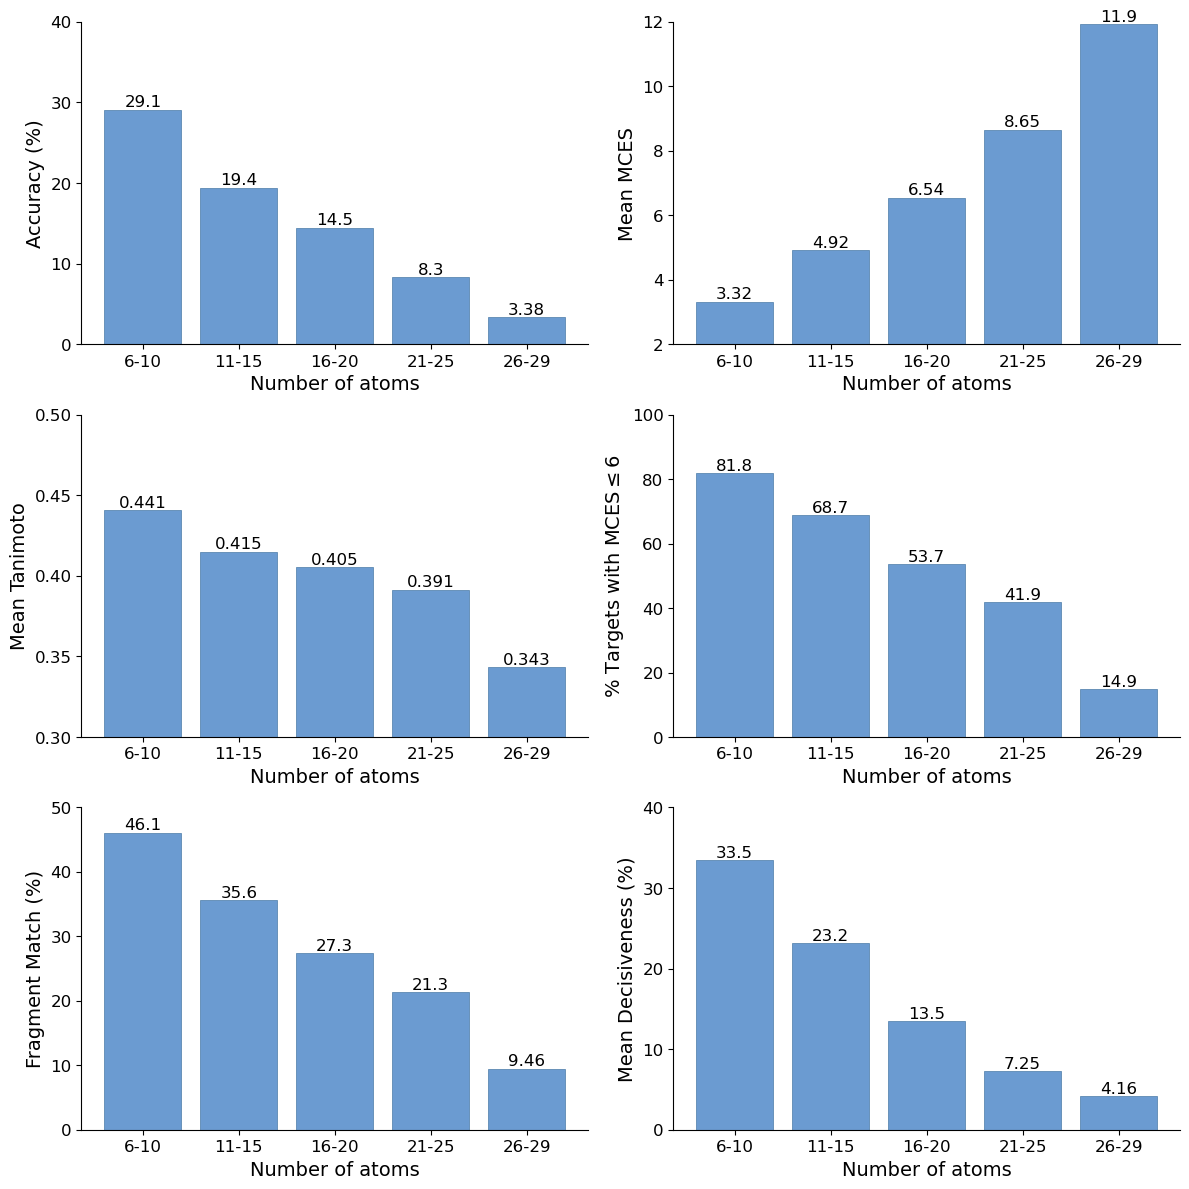

{'accuracy':      bin      value  count  bin_lo  bin_hi
 0   6-10  29.090909    165       6      10
 1  11-15  19.444444    540      11      15
 2  16-20  14.489796    490      16      20
 3  21-25   8.303249    277      21      25
 4  26-29   3.378378    148      26      29,
 'topn_min_mces':      bin      value  count  bin_lo  bin_hi
 0   6-10   3.324242    165       6      10
 1  11-15   4.918519    540      11      15
 2  16-20   6.542857    490      16      20
 3  21-25   8.653430    277      21      25
 4  26-29  11.922297    148      26      29,
 'topn_max_tanimoto':      bin     value  count  bin_lo  bin_hi
 0   6-10  0.440842    165       6      10
 1  11-15  0.414866    540      11      15
 2  16-20  0.405463    490      16      20
 3  21-25  0.391414    277      21      25
 4  26-29  0.343440    148      26      29,
 'pct_targets_min_mces':      bin      value  count  bin_lo  bin_hi
 0   6-10  81.818182    165       6      10
 1  11-15  68.703704    540      11      15
 2  1

In [22]:
csv_path = os.path.join("analysis_outputs/csv", f"{name}_top{n}.csv")

yticks_dict = {
    "accuracy": (0, 40, 10),
    "topn_min_mces": (2, 12, 2),
    "topn_max_tanimoto": (0.30, 0.50, 0.05),
    "pct_targets_min_mces": (0, 100, 20),
    "decisiveness": (0, 40, 10),
    "fragment_match": (0, 50, 10),
}

plot_all_metrics_by_atom_bins(
    csv_path,
    n=n,
    upper_limit=29,  # Default, can be changed
    overflow="clip",  # Default, creates "30+" bin
    yticks_dict=yticks_dict,
    save_path=f"analysis_outputs/plots/{name}_all_metrics_by_size.png",
)

### 3. Plotting by Data Depth

In [14]:
# Load graph dictionary to get data depth information

import torch

graph_dict_path = "/gpfs0/bgu-anatm/users/harniky/ms2mol/Preprocessing/NIST/smiles_dict_nist2.pt"
graph_dict = torch.load(graph_dict_path, weights_only=False)

# Canonicalize SMILES keys for matching
graph_dict_canonical = {}
for smi in graph_dict.keys():
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        canonical_smiles = Chem.MolToSmiles(mol)
        graph_dict_canonical[canonical_smiles] = graph_dict[smi]

/gpfs0/bgu-anatm/users/harniky/env/ms2mol/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
from typing import Dict, Tuple, Optional, List, Union
from pathlib import Path

def plot_all_metrics_by_data_depth(
    smiles_dict: Dict[str, Any],
    csv_path: Union[str, Path],
    n: int,
    *,
    metrics: Optional[List[MetricName]] = None,
    yticks_dict: Optional[Dict[MetricName, Tuple[float, float, float]]] = None,
    bin_size: int = 6,
    upper_limit: Optional[int] = 24,
    overflow: OverflowMode = "unbounded",
    save_path: Optional[str] = None,
    show_values_on_bars: bool = True,
):
    """Plot multiple metrics vs data-depth bins in a single 2x3 grid figure.

    By default plots the following 6 metrics (if available in the CSV):
    - accuracy
    - topn_min_mces
    - topn_max_tanimoto
    - pct_targets_min_mces
    - decisiveness
    - fragment_match
    
    Args:
        smiles_dict: Dictionary mapping SMILES to data (used to extract data depth)
        csv_path: Path to CSV file with evaluation results
        n: Top-N value used in the evaluation
        metrics: List of metrics to plot. Defaults to all 6 metrics.
        yticks_dict: Optional dict mapping metric names to (min, max, step) for y-axis ticks
        bin_size: Size of each bin (default: 6)
        upper_limit: Maximum data depth to bin normally. Values above this are handled
                     according to overflow mode (default: 24)
        overflow: How to handle values above upper_limit: "unbounded" (create "25+" bin),
                  "bin" (create ">24" bin), "drop" (exclude), or "clip" (treat as upper_limit)
        save_path: Optional path to save the figure
        show_values_on_bars: Whether to display values on top of bars
    """
    if metrics is None:
        metrics = [
            "accuracy",
            "topn_min_mces",
            "topn_max_tanimoto",
            "pct_targets_min_mces",
            "fragment_match",
            "decisiveness",
        ]

    # 1) Extract data depths from dict
    size_rows = []
    for tgt, lst in smiles_dict.items():
        sz = _first_size(lst)
        if sz is not None:
            size_rows.append((tgt, sz))
    sizes_df = pd.DataFrame(size_rows, columns=["target", "first_size"])

    # 2) Load metrics CSV
    csv_path = Path(csv_path)
    met_df = pd.read_csv(csv_path)

    # Ensure numeric columns
    for col in [
        "topn_hit_int",
        "topn_min_mces",
        "topn_max_tanimoto",
        "topn_min_mces_le_threshold",
        "topn_fragment_match",
        "decisiveness",
    ]:
        if col in met_df.columns:
            met_df[col] = pd.to_numeric(met_df[col], errors="coerce")

    # 3) Merge
    df = sizes_df.merge(met_df, on="target", how="inner")

    # 4) Bin by first_size
    df["size_bin"] = df["first_size"].apply(
        lambda x: _size_bin_label(int(x), bin_size=bin_size, upper_limit=upper_limit, overflow=overflow)
    )
    # Drop rows that were intentionally dropped by overflow="drop"
    df = df.dropna(subset=["size_bin"]).copy()

    # Prepare figure
    fig, axes = plt.subplots(3, 2, figsize=(12, 12))
    axes = axes.flatten()

    # Helper to configure metric mapping
    def _metric_cfg(metric_name: MetricName):
        if metric_name == "accuracy":
            col = "topn_hit_int"
            agg_fn = lambda s: float(s.dropna().mean() * 100.0) if len(s.dropna()) else float("nan")
            ylabel = f"Accuracy (%)"
        elif metric_name == "topn_min_mces":
            col = "topn_min_mces"
            agg_fn = lambda s: float(s.dropna().mean()) if len(s.dropna()) else float("nan")
            ylabel = f"Mean MCES"
        elif metric_name == "topn_max_tanimoto":
            col = "topn_max_tanimoto"
            agg_fn = lambda s: float(s.dropna().mean()) if len(s.dropna()) else float("nan")
            ylabel = f"Mean Tanimoto"
        elif metric_name == "pct_targets_min_mces":
            col = "topn_min_mces_le_threshold"
            agg_fn = lambda s: float(s.dropna().mean() * 100.0) if len(s.dropna()) else float("nan")
            ylabel = r"% Targets with MCES$\leq$6"
        elif metric_name == "decisiveness":
            col = "decisiveness"
            agg_fn = lambda s: float(s.dropna().mean()) if len(s.dropna()) else float("nan")
            ylabel = f"Mean Decisiveness (%)"
        elif metric_name == "fragment_match":
            col = "topn_fragment_match"
            agg_fn = lambda s: float(s.dropna().mean() * 100.0) if len(s.dropna()) else float("nan")
            ylabel = f"Fragment Match (%)"
        else:
            raise ValueError(f"Unknown metric: {metric_name}")
        return col, agg_fn, ylabel

    plotted = []

    for ax, metric_name in zip(axes, metrics):
        col, agg_fn, ylabel = _metric_cfg(metric_name)

        if col not in df.columns:
            ax.axis("off")
            ax.set_title(f"{metric_name} (missing)")
            continue

        # Aggregate per bin
        grouped = df.groupby("size_bin")[col].apply(agg_fn).reset_index(name="value")
        counts = df.groupby("size_bin")["target"].count().reset_index(name="count")
        out = pd.merge(grouped, counts, on="size_bin", how="outer").fillna(0)

        # Sort by numeric bounds
        out["bin_lo"], out["bin_hi"] = zip(*out["size_bin"].map(_bin_bounds))
        out = out.rename(columns={"size_bin": "bin"}).sort_values(["bin_lo", "bin_hi"]).reset_index(drop=True)

        x = np.arange(len(out))
        bar_color = "#6B9BD1"
        bars = ax.bar(x, out["value"], color=bar_color, edgecolor="#4A7BA7", linewidth=0.5)

        ax.set_xticks(x)
        ax.set_xticklabels(out["bin"], fontsize=12)
        ax.set_xlabel("data depth", fontsize=14)
        ax.set_ylabel(ylabel, fontsize=14)
        ax.tick_params(axis="y", labelsize=12)

        # Apply per-metric yticks if provided
        if yticks_dict is not None and metric_name in yticks_dict:
            y0, y1, dy = yticks_dict[metric_name]
            ax.set_yticks(np.arange(y0, y1 + dy, dy))
            ax.set_ylim(y0, y1)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if show_values_on_bars:
            for xi, val in zip(x, out["value"].values):
                if isinstance(val, (float, int)) and not (isinstance(val, float) and math.isnan(val)):
                    ax.text(xi, val, f"{val:.3g}", ha="center", va="bottom", fontsize=12)

        plotted.append((metric_name, out))

    # Hide any unused axes if fewer than 6 metrics
    for ax in axes[len(metrics):]:
        ax.axis("off")

    plt.tight_layout()
    if save_path:
        if not any(save_path.endswith(ext) for ext in [".svg", ".png", ".pdf", ".jpg", ".jpeg", ".eps"]):
            save_path = str(save_path) + ".png"
        plt.savefig(save_path, bbox_inches="tight", format="svg" if save_path.endswith(".svg") else None, dpi=300)

    plt.show()

    # Return a dict of data frames per metric
    return {m: df_out for (m, df_out) in plotted}

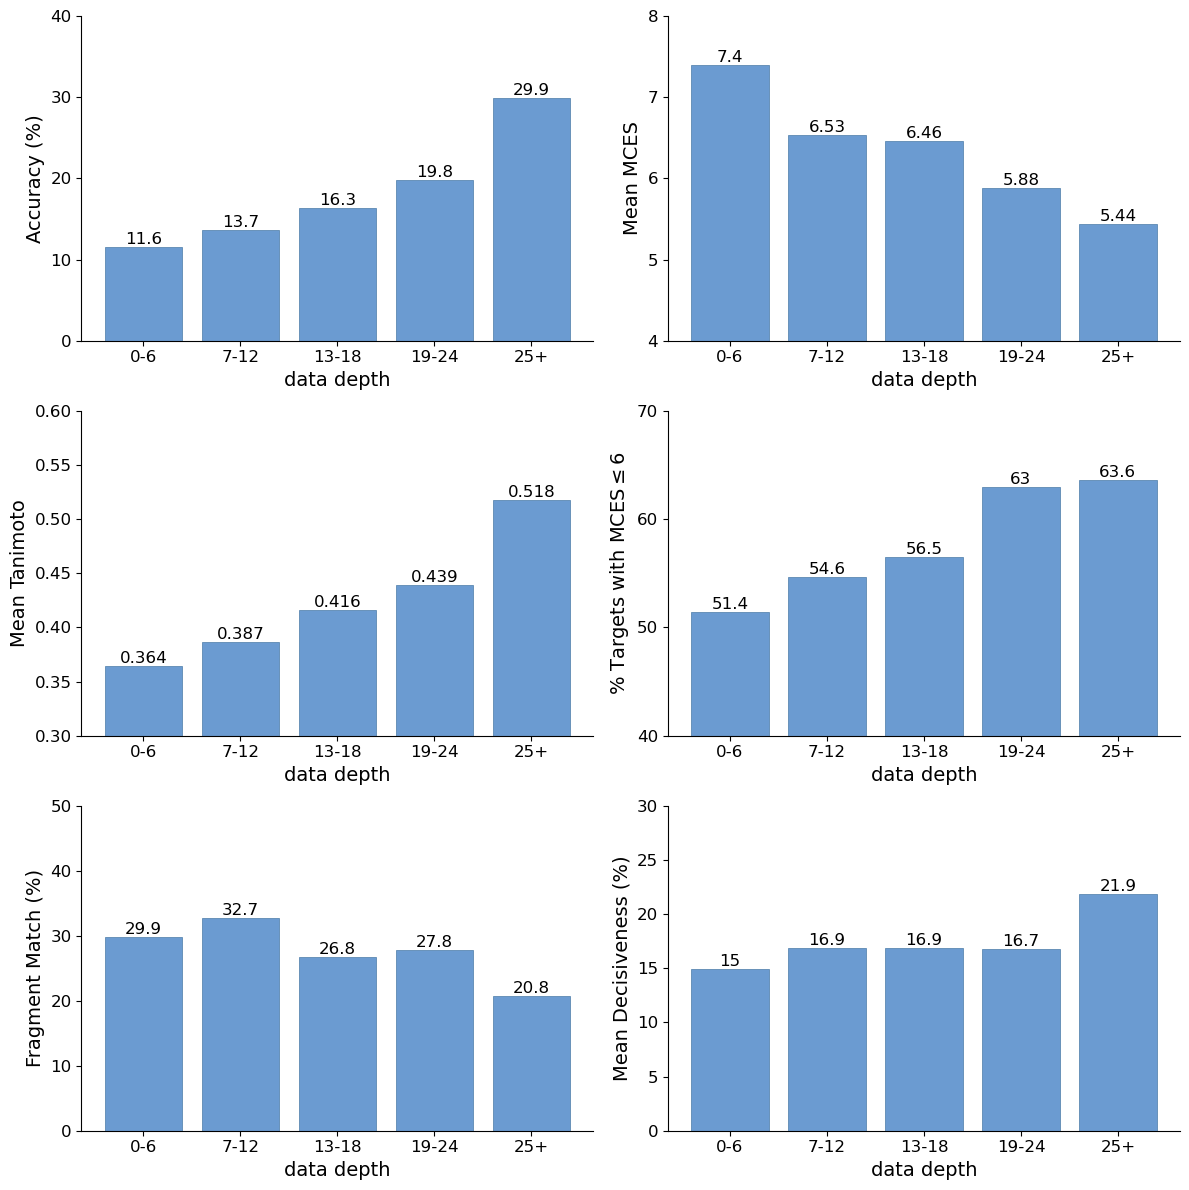

{'accuracy':      bin      value  count  bin_lo  bin_hi
 0    0-6  11.553785    251       0     6.0
 1   7-12  13.658537    615       7    12.0
 2  13-18  16.310680    515      13    18.0
 3  19-24  19.753086    162      19    24.0
 4    25+  29.870130     77      25     inf,
 'topn_min_mces':      bin     value  count  bin_lo  bin_hi
 0    0-6  7.398406    251       0     6.0
 1   7-12  6.534959    615       7    12.0
 2  13-18  6.457282    515      13    18.0
 3  19-24  5.876543    162      19    24.0
 4    25+  5.435065     77      25     inf,
 'topn_max_tanimoto':      bin     value  count  bin_lo  bin_hi
 0    0-6  0.364296    251       0     6.0
 1   7-12  0.386816    615       7    12.0
 2  13-18  0.416244    515      13    18.0
 3  19-24  0.438931    162      19    24.0
 4    25+  0.518069     77      25     inf,
 'pct_targets_min_mces':      bin      value  count  bin_lo  bin_hi
 0    0-6  51.394422    251       0     6.0
 1   7-12  54.634146    615       7    12.0
 2  13-18  

In [21]:
csv_path = os.path.join("analysis_outputs/csv", f"{name}_top{n}.csv")

yticks_dict = {
    "accuracy": (0, 40, 10),
    "topn_min_mces": (4, 8, 1),
    "topn_max_tanimoto": (0.30, 0.60, 0.05),
    "pct_targets_min_mces": (40, 70, 10),
    "fragment_match": (0, 50, 10),
    "decisiveness": (0, 30, 5),
}

plot_all_metrics_by_data_depth(
    graph_dict_canonical,
    csv_path,
    n=n,
    bin_size=6,
    upper_limit=24,
    overflow="unbounded",
    yticks_dict=yticks_dict,
    save_path=f"analysis_outputs/plots/{name}_all_metrics_by_depth.png",
)